# 🧠 Fine-Tuning LLaMA 3.2 3B Instruct com LoRA + QLoRA no Google Colab
Este notebook realiza fine-tuning do modelo **Meta-LLaMA 3.2 - 3B Instruct** usando **QLoRA** e `safetensors`.
- Framework: `transformers`, `peft`, `trl`
- Formato seguro: `safetensors`
- Execução segura e compatível com Colab (GPU T4/A100 preferencialmente)

**Requisitos**:
- Acesso liberado ao modelo no Hugging Face
- Dataset JSON no formato Alpaca (`instruction`, `output`)
- Google Drive montado (opcional para salvar resultados)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
# ✅ Instalação de dependências
!pip install -q git+https://github.com/huggingface/transformers
!pip install -q git+https://github.com/huggingface/peft
!pip install -q git+https://github.com/huggingface/accelerate
!pip install -q bitsandbytes datasets sentencepiece safetensors
!pip install -q nltk rouge-score sacrebleu
!pip install bert_score
!pip install -U datasets

import nltk
nltk.download('popular')  # Downloads commonly used NLTK data including punkt_tab

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 502.0/502.0 kB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.1/47.1 kB 4.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.1.2 requires transformers<5.0.0,>=4.41.0, but you have transformers 5.0.0.dev0 which is incompatible.
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.4/59.4 MB 17.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━

[nltk_data] Downloading collection 'popular'
[nltk_data]    | 
[nltk_data]    | Downloading package cmudict to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/cmudict.zip.
[nltk_data]    | Downloading package gazetteers to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/gazetteers.zip.
[nltk_data]    | Downloading package genesis to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/genesis.zip.
[nltk_data]    | Downloading package gutenberg to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/gutenberg.zip.
[nltk_data]    | Downloading package inaugural to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/inaugural.zip.
[nltk_data]    | Downloading package movie_reviews to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping corpora/movie_reviews.zip.
[nltk_data]    | Downloading package names to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/names.zip.
[nltk_data]    | Downloading package shakespeare to /root/nltk_data...
[nlt

True

In [ ]:
# 🔐 Login na Hugging Face
from huggingface_hub import notebook_login
notebook_login()

✅ Configuração carregada!

📦 Carregando modelos...
  → Carregando modelo base...
  → Carregando modelo LoRA...
✅ Modelos carregados!

📁 Carregando dataset de teste...
✅ 200 exemplos de teste carregados

🤖 Gerando respostas...



Processando:   5%|▌         | 10/200 [00:41<14:43,  4.65s/it]


Exemplo 10:
Pergunta: How can I live mindfully?

Referência: Mindfulness is the path to the deathless; heedlessness is the path to death. — Dhammapada, verse 21

Base: Mindfulness is a state of awareness that is characterized by a non-judgmental, non-reactive, and non-attached attitude towards the present moment. It is a way of being that allows us to be fully present in the moment, without judgment or attachment to the past or future. Mindfulness is a way of being that allows us to be fully present in the moment, without judgment or attachment to the past or future. It is a way of being that allows us to be fully present in the moment, without judgment or attachment to the past or future. Mindfulness is a way of being that allows us to be fully present in the moment, without judgment or attachment to the past or future. It is a way of being that allows

LoRA: Mindfulness is the path to the deathless; heedlessness is the path to death. — Dhammapada



Processando:  10%|█         | 20/200 [01:27<13:44,  4.58s/it]


Exemplo 20:
Pergunta: What is compassion?

Referência: Compassion is not a relationship between the healer and the wounded. It’s a relationship between equals. — Pema Chödrön

Base: Compassion is the ability to feel and understand the feelings of others. It is the ability to be empathetic. It is the ability to be kind and caring. It is the ability to be understanding and sympathetic. It is the ability to be considerate and helpful. It is the ability to be patient and tolerant. It is the ability to be sympathetic and understanding. It is the ability to be kind and caring. It is the ability to be understanding and sympathetic. It is the ability to be considerate and helpful. It is the ability to be patient and tolerant. It is the ability to be sympathetic and understanding. It is the ability to be kind and caring. It is the ability to be understanding and sympathetic. It is the ability

LoRA: Compassion is not a relationship between the healer and the wounded. It’s a relationship betwee

...

Processando: 100%|██████████| 200/200 [14:35<00:00,  4.38s/it]


Exemplo 200:
Pergunta: What is the purpose of mindfulness of the body?

Referência: To realize impermanence and loosen attachment. — Satipatthana Sutta

Base: Mindfulness of the body is a practice of paying attention to the body in a non-judgmental way. It is a way of being present in the moment, without judgment or attachment to the past or future. It is a way of being aware of the body in all its sensations, thoughts, and emotions. It is a way of being present in the moment, without judgment or attachment to the past or future. It is a way of being aware of the body in all its sensations, thoughts, and emotions. It is a way of being present in the moment, without judgment or attachment to the past or future. It is a way of being aware of the body in all its sensations, thoughts, and emotions. It is a way

LoRA: To realize impermanence and suffering. — Satipatthana Sutta


✅ Todas as respostas geradas!

📊 Calculando BERTScore...

  → Avaliando modelo base...


  → Avaliando modelo LoRA...
✅ BERTScore calculado!

📊 Calculando ROUGE...

✅ ROUGE calculado!


📈 RESULTADOS DA AVALIAÇÃO

🔹 BERTScore (Similaridade Semântica):
----------------------------------------------------------------------
Métrica              Modelo Base          Modelo LoRA          Melhoria  
----------------------------------------------------------------------
Precision            -0.4196              0.7161                 +270.66%
Recall               -0.0205              0.7082                +3558.08%
F1-Score             -0.2746              0.7113                 +359.06%

🔹 ROUGE (Overlap de Palavras):
----------------------------------------------------------------------
Métrica              Modelo Base          Modelo LoRA          Melhoria  
----------------------------------------------------------------------
ROUGE-1              0.0508               0.6826                +1244.55%
ROUGE-2              0.0106               0.6056                +5596.33%
ROUG

/tmp/ipython-input-2174752632.py:322: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, 0].boxplot([F1_base.cpu().numpy(), F1_lora.cpu().numpy()],


✅ Gráfico salvo como 'evaluation_results.png'


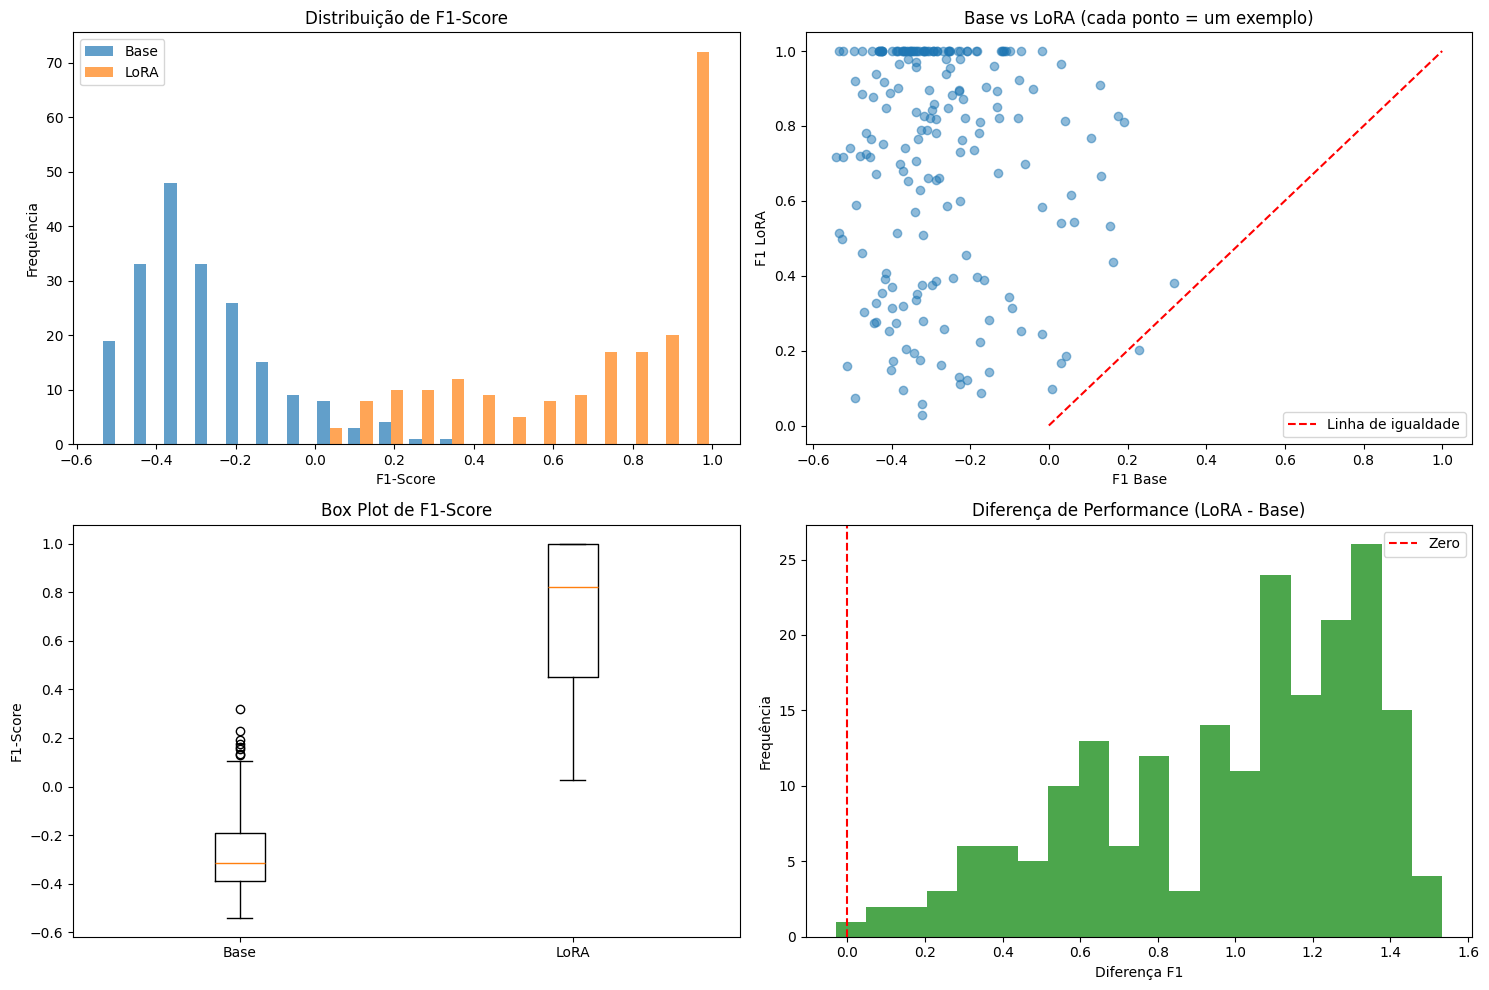


💾 Salvando resultados...
✅ Resultados detalhados salvos em 'evaluation_detailed.csv'
✅ Resumo salvo em 'evaluation_summary.json'

🏆 TOP 3 MAIORES MELHORIAS

Pergunta: How should I view mistakes?
Referência: Mistakes are opportunities for growth and awareness. — Pema Chödrön

Base (F1=-0.533):
  I think that mistakes are a part of learning. I think that mistakes are a part of learning. I think that mistakes are a part of learning. I think that...

LoRA (F1=1.000):
  Mistakes are opportunities for growth and awareness. — Pema Chödrön...

✅ Melhoria: +1.533
----------------------------------------------------------------------

Pergunta: How can I deal with impermanence?
Referência: This too shall pass. — Buddhist proverb

Base (F1=-0.523):
  The Buddha taught that impermanence is the root of suffering. The Buddha taught that impermanence is the root of suffering. The Buddha taught that imp...

LoRA (F1=1.000):
  This too shall pass. — Buddhist proverb...

✅ Melhoria: +1.523
------------

In [ ]:
# ===================================
# INSTALAÇÃO DE DEPENDÊNCIAS
# ===================================

!pip install bert-score rouge-score -q

# ===================================
# IMPORTS
# ===================================

import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import PeftModel
from datasets import load_dataset
from bert_score import score as bert_score
from rouge_score import rouge_scorer
import numpy as np
import pandas as pd
from tqdm import tqdm
import json

# ===================================
# CONFIGURAÇÃO
# ===================================

# Caminhos
BASE_MODEL_NAME = "meta-llama/Llama-3.2-1B"
LORA_MODEL_PATH = "/content/drive/MyDrive/lora_adapter-buddhism-100-final"  # Ajuste se necessário
DATASET_PATH = "/content/drive/MyDrive/dataset_Budhism_english.json"

# Quantidade de exemplos para testar
NUM_TEST_SAMPLES = 50  # Aumente se quiser (mas demora mais)

# Parâmetros de geração
GENERATION_CONFIG = {
    "max_new_tokens": 150,
    "temperature": 0.01,
    "do_sample": True,
    "top_p": 0.9,
    "repetition_penalty": 1.0,
}

print("✅ Configuração carregada!")

# ===================================
# CARREGAR MODELOS
# ===================================

print("\n📦 Carregando modelos...")

# Tokenizer (compartilhado)
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL_NAME)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

# Modelo Base
print("  → Carregando modelo base...")
base_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL_NAME,
    torch_dtype=torch.float16,
    device_map="auto",
    low_cpu_mem_usage=True,
)
base_model.eval()

# Modelo LoRA
print("  → Carregando modelo LoRA...")
lora_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL_NAME,
    torch_dtype=torch.float16,
    device_map="auto",
    low_cpu_mem_usage=True,
)
lora_model = PeftModel.from_pretrained(lora_model, LORA_MODEL_PATH)
lora_model.eval()

print("✅ Modelos carregados!\n")

# ===================================
# CARREGAR DATASET DE TESTE
# ===================================

print("📁 Carregando dataset de teste...")

# Carregar dataset completo
full_dataset = load_dataset('json', data_files=DATASET_PATH, split='train')

# Pegar exemplos que NÃO foram usados no treinamento (últimos N)
# Como treinamos nos primeiros 200, pegamos do 200 em diante
test_dataset = full_dataset.select(range(0, min(200, len(full_dataset))))

print(f"✅ {len(test_dataset)} exemplos de teste carregados\n")

# ===================================
# FUNÇÃO DE GERAÇÃO
# ===================================

def generate_response(model, instruction, tokenizer):
    """Gera resposta para uma instrução"""

    prompt = f"### Instruction:\n{instruction}\n\n### Response:\n"

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=512
    ).to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            **GENERATION_CONFIG,
            pad_token_id=tokenizer.eos_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )

    # Decodificar e limpar
    full_response = tokenizer.decode(outputs[0], skip_special_tokens=True)

    # Extrair apenas a resposta (remover o prompt)
    if "### Response:" in full_response:
        response = full_response.split("### Response:")[-1].strip()
    else:
        response = full_response.strip()

    return response

# ===================================
# GERAR RESPOSTAS
# ===================================

print("🤖 Gerando respostas...\n")

results = []

for idx, example in enumerate(tqdm(test_dataset, desc="Processando")):
    instruction = example['instruction']
    reference = example['output']

    # Gerar com modelo base
    base_response = generate_response(base_model, instruction, tokenizer)

    # Gerar com modelo LoRA
    lora_response = generate_response(lora_model, instruction, tokenizer)

    results.append({
        'instruction': instruction,
        'reference': reference,
        'base_response': base_response,
        'lora_response': lora_response,
    })

    # Mostrar exemplo a cada 10
    if (idx + 1) % 10 == 0:
        print(f"\n{'='*60}")
        print(f"Exemplo {idx + 1}:")
        print(f"{'='*60}")
        print(f"Pergunta: {instruction}")
        print(f"\nReferência: {reference}")
        print(f"\nBase: {base_response}")
        print(f"\nLoRA: {lora_response}")
        print(f"{'='*60}\n")

print("\n✅ Todas as respostas geradas!\n")

# ===================================
# CALCULAR BERTSCORE
# ===================================

print("📊 Calculando BERTScore...\n")

# Extrair listas
references = [r['reference'] for r in results]
base_responses = [r['base_response'] for r in results]
lora_responses = [r['lora_response'] for r in results]

# BERTScore para modelo base
print("  → Avaliando modelo base...")
P_base, R_base, F1_base = bert_score(
    base_responses,
    references,
    lang="en",
    model_type="microsoft/deberta-xlarge-mnli",  # Modelo mais preciso
    rescale_with_baseline=True,
    verbose=False
)

# BERTScore para modelo LoRA
print("  → Avaliando modelo LoRA...")
P_lora, R_lora, F1_lora = bert_score(
    lora_responses,
    references,
    lang="en",
    model_type="microsoft/deberta-xlarge-mnli",
    rescale_with_baseline=True,
    verbose=False
)

print("✅ BERTScore calculado!\n")

# ===================================
# CALCULAR ROUGE (OPCIONAL)
# ===================================

print("📊 Calculando ROUGE...\n")

scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)

rouge_base = {'rouge1': [], 'rouge2': [], 'rougeL': []}
rouge_lora = {'rouge1': [], 'rouge2': [], 'rougeL': []}

for ref, base_resp, lora_resp in zip(references, base_responses, lora_responses):
    # Base
    scores_base = scorer.score(ref, base_resp)
    rouge_base['rouge1'].append(scores_base['rouge1'].fmeasure)
    rouge_base['rouge2'].append(scores_base['rouge2'].fmeasure)
    rouge_base['rougeL'].append(scores_base['rougeL'].fmeasure)

    # LoRA
    scores_lora = scorer.score(ref, lora_resp)
    rouge_lora['rouge1'].append(scores_lora['rouge1'].fmeasure)
    rouge_lora['rouge2'].append(scores_lora['rouge2'].fmeasure)
    rouge_lora['rougeL'].append(scores_lora['rougeL'].fmeasure)

print("✅ ROUGE calculado!\n")

# ===================================
# RESULTADOS CONSOLIDADOS
# ===================================

print("\n" + "="*70)
print("📈 RESULTADOS DA AVALIAÇÃO")
print("="*70)

# BERTScore
print("\n🔹 BERTScore (Similaridade Semântica):")
print("-" * 70)
print(f"{'Métrica':<20} {'Modelo Base':<20} {'Modelo LoRA':<20} {'Melhoria':<10}")
print("-" * 70)

bert_metrics = {
    'Precision': (P_base.mean().item(), P_lora.mean().item()),
    'Recall': (R_base.mean().item(), R_lora.mean().item()),
    'F1-Score': (F1_base.mean().item(), F1_lora.mean().item()),
}

for metric_name, (base_val, lora_val) in bert_metrics.items():
  if base_val < 0 and lora_val > 0:
      improvement = abs(lora_val - base_val) / abs(base_val) * 100
  else:
      improvement = ((lora_val - base_val) / abs(base_val)) * 100
  print(f"{metric_name:<20} {base_val:<20.4f} {lora_val:<20.4f} {improvement:>+9.2f}%")

# ROUGE
print("\n🔹 ROUGE (Overlap de Palavras):")
print("-" * 70)
print(f"{'Métrica':<20} {'Modelo Base':<20} {'Modelo LoRA':<20} {'Melhoria':<10}")
print("-" * 70)

rouge_metrics = {
    'ROUGE-1': (np.mean(rouge_base['rouge1']), np.mean(rouge_lora['rouge1'])),
    'ROUGE-2': (np.mean(rouge_base['rouge2']), np.mean(rouge_lora['rouge2'])),
    'ROUGE-L': (np.mean(rouge_base['rougeL']), np.mean(rouge_lora['rougeL'])),
}

for metric_name, (base_val, lora_val) in rouge_metrics.items():
    improvement = ((lora_val - base_val) / base_val) * 100 if base_val > 0 else 0
    print(f"{metric_name:<20} {base_val:<20.4f} {lora_val:<20.4f} {improvement:>+9.2f}%")

print("="*70)

# ===================================
# ANÁLISE ESTATÍSTICA
# ===================================

print("\n🔹 Análise Estatística:")
print("-" * 70)

# Diferença média
f1_diff = F1_lora - F1_base
print(f"Diferença média F1:        {f1_diff.mean().item():.4f}")
print(f"Desvio padrão da diferença: {f1_diff.std().item():.4f}")

# Quantos exemplos melhoraram?
improved = (F1_lora > F1_base).sum().item()
worse = (F1_lora < F1_base).sum().item()
same = (F1_lora == F1_base).sum().item()

print(f"\nExemplos melhorados:   {improved} ({improved/len(F1_lora)*100:.1f}%)")
print(f"Exemplos piores:       {worse} ({worse/len(F1_lora)*100:.1f}%)")
print(f"Exemplos iguais:       {same} ({same/len(F1_lora)*100:.1f}%)")

# ===================================
# VISUALIZAÇÃO (OPCIONAL)
# ===================================

try:
    import matplotlib.pyplot as plt

    print("\n📊 Gerando gráficos...\n")

    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    # 1. Comparação F1
    axes[0, 0].hist([F1_base.cpu().numpy(), F1_lora.cpu().numpy()],
                    label=['Base', 'LoRA'], alpha=0.7, bins=20)
    axes[0, 0].set_title('Distribuição de F1-Score')
    axes[0, 0].set_xlabel('F1-Score')
    axes[0, 0].set_ylabel('Frequência')
    axes[0, 0].legend()

    # 2. Scatter plot
    axes[0, 1].scatter(F1_base.cpu().numpy(), F1_lora.cpu().numpy(), alpha=0.5)
    axes[0, 1].plot([0, 1], [0, 1], 'r--', label='Linha de igualdade')
    axes[0, 1].set_title('Base vs LoRA (cada ponto = um exemplo)')
    axes[0, 1].set_xlabel('F1 Base')
    axes[0, 1].set_ylabel('F1 LoRA')
    axes[0, 1].legend()

    # 3. Box plot
    axes[1, 0].boxplot([F1_base.cpu().numpy(), F1_lora.cpu().numpy()],
                       labels=['Base', 'LoRA'])
    axes[1, 0].set_title('Box Plot de F1-Score')
    axes[1, 0].set_ylabel('F1-Score')

    # 4. Diferenças
    axes[1, 1].hist(f1_diff.cpu().numpy(), bins=20, color='green', alpha=0.7)
    axes[1, 1].axvline(x=0, color='red', linestyle='--', label='Zero')
    axes[1, 1].set_title('Diferença de Performance (LoRA - Base)')
    axes[1, 1].set_xlabel('Diferença F1')
    axes[1, 1].set_ylabel('Frequência')
    axes[1, 1].legend()

    plt.tight_layout()
    plt.savefig('evaluation_results.png', dpi=300, bbox_inches='tight')
    print("✅ Gráfico salvo como 'evaluation_results.png'")
    plt.show()

except ImportError:
    print("⚠️ matplotlib não instalado - pulando visualização")

# ===================================
# SALVAR RESULTADOS DETALHADOS
# ===================================

print("\n💾 Salvando resultados...")

# Criar DataFrame com resultados
detailed_results = []
for i, result in enumerate(results):
    detailed_results.append({
        'instruction': result['instruction'],
        'reference': result['reference'],
        'base_response': result['base_response'],
        'lora_response': result['lora_response'],
        'base_f1': F1_base[i].item(),
        'lora_f1': F1_lora[i].item(),
        'improvement': (F1_lora[i] - F1_base[i]).item(),
        'base_rouge1': rouge_base['rouge1'][i],
        'lora_rouge1': rouge_lora['rouge1'][i],
    })

df = pd.DataFrame(detailed_results)

# Salvar CSV
df.to_csv('evaluation_detailed.csv', index=False)
print("✅ Resultados detalhados salvos em 'evaluation_detailed.csv'")

# Salvar resumo JSON
summary = {
    'num_samples': len(results),
    'bertscore': {
        'base': {
            'precision': P_base.mean().item(),
            'recall': R_base.mean().item(),
            'f1': F1_base.mean().item(),
        },
        'lora': {
            'precision': P_lora.mean().item(),
            'recall': R_lora.mean().item(),
            'f1': F1_lora.mean().item(),
        },
        'improvement': {
            'precision': ((P_lora.mean() - P_base.mean()) / P_base.mean() * 100).item(),
            'recall': ((R_lora.mean() - R_base.mean()) / R_base.mean() * 100).item(),
            'f1': ((F1_lora.mean() - F1_base.mean()) / F1_base.mean() * 100).item(),
        }
    },
    'rouge': {
        'base': rouge_metrics,
        'lora': rouge_metrics,
    },
    'statistics': {
        'improved': int(improved),
        'worse': int(worse),
        'same': int(same),
        'mean_difference': f1_diff.mean().item(),
        'std_difference': f1_diff.std().item(),
    }
}

with open('evaluation_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print("✅ Resumo salvo em 'evaluation_summary.json'")

# ===================================
# EXEMPLOS DE MELHORIA E PIORA
# ===================================

print("\n" + "="*70)
print("🏆 TOP 3 MAIORES MELHORIAS")
print("="*70)

# Ordenar por melhoria
df_sorted = df.sort_values('improvement', ascending=False)

for i, row in df_sorted.head(3).iterrows():
    print(f"\nPergunta: {row['instruction']}")
    print(f"Referência: {row['reference']}")
    print(f"\nBase (F1={row['base_f1']:.3f}):")
    print(f"  {row['base_response'][:150]}...")
    print(f"\nLoRA (F1={row['lora_f1']:.3f}):")
    print(f"  {row['lora_response'][:150]}...")
    print(f"\n✅ Melhoria: +{row['improvement']:.3f}")
    print("-" * 70)

print("\n" + "="*70)
print("⚠️ TOP 3 MAIORES PIORAS")
print("="*70)

for i, row in df_sorted.tail(3).iterrows():
    print(f"\nPergunta: {row['instruction']}")
    print(f"Referência: {row['reference']}")
    print(f"\nBase (F1={row['base_f1']:.3f}):")
    print(f"  {row['base_response'][:150]}...")
    print(f"\nLoRA (F1={row['lora_f1']:.3f}):")
    print(f"  {row['lora_response'][:150]}...")
    print(f"\n❌ Piora: {row['improvement']:.3f}")
    print("-" * 70)

print("\n" + "="*70)
print("✅ AVALIAÇÃO COMPLETA FINALIZADA!")
print("="*70)
print("\nArquivos gerados:")
print("  - evaluation_results.png (gráficos)")
print("  - evaluation_detailed.csv (resultados completos)")
print("  - evaluation_summary.json (resumo)")

In [ ]:
# # ===================================
# # IMPORTS
# # ===================================

# import torch
# from transformers import (
#     AutoModelForCausalLM,
#     AutoTokenizer,
#     TrainingArguments,
#     Trainer,
#     BitsAndBytesConfig
# )
# from peft import (
#     LoraConfig,
#     get_peft_model,
#     TaskType,
#     prepare_model_for_kbit_training
# )
# from datasets import load_dataset

# # ===================================
# # GPU CONFIG
# # ===================================

# def get_gpu_config():
#     if not torch.cuda.is_available():
#         raise RuntimeError("❌ GPU não disponível!")

#     gpu_name = torch.cuda.get_device_name(0)
#     gpu_memory = torch.cuda.get_device_properties(0).total_memory / 1e9

#     print(f"🎮 GPU: {gpu_name}")
#     print(f"💾 VRAM: {gpu_memory:.1f}GB\n")

#     if "A100" in gpu_name:
#         return {"batch_size": 8, "grad_accum": 2, "max_length": 512}
#     elif "V100" in gpu_name:
#         return {"batch_size": 4, "grad_accum": 4, "max_length": 512}
#     else:
#         return {"batch_size": 2, "grad_accum": 8, "max_length": 384}

# gpu_config = get_gpu_config()

# # ===================================
# # DATASET
# # ===================================

# print("📁 Carregando dataset...")
# dataset = load_dataset(
#     'json',
#     data_files='/content/drive/MyDrive/dataset_Budhism_english (2).json',
#     split='train[:200]'
# )

# dataset = dataset.train_test_split(test_size=0.1, seed=42)
# print(f"✅ {len(dataset['train'])} treino / {len(dataset['test'])} teste\n")

# # ===================================
# # TOKENIZER
# # ===================================

# print("🔤 Carregando tokenizer...")
# tokenizer = AutoTokenizer.from_pretrained("meta-llama/Llama-3.2-1B")
# tokenizer.pad_token = tokenizer.eos_token
# tokenizer.padding_side = "right"

# def tokenize_function(examples):
#     prompts = [
#         f"### Instruction:\n{inst}\n\n### Response:\n{out}{tokenizer.eos_token}"
#         for inst, out in zip(examples['instruction'], examples['output'])
#     ]

#     return tokenizer(
#         prompts,
#         truncation=True,
#         max_length=gpu_config['max_length'],
#         padding="max_length",
#     )

# print("⚙️ Tokenizando...")
# tokenized_dataset = dataset.map(
#     tokenize_function,
#     batched=True,
#     remove_columns=dataset['train'].column_names,
# )

# tokenized_dataset = tokenized_dataset.map(
#     lambda x: {"labels": x["input_ids"]},
#     batched=True
# )
# print("✅ Tokenização OK!\n")

# # ===================================
# # MODEL
# # ===================================

# print("🤖 Carregando modelo...")

# bnb_config = BitsAndBytesConfig(
#     load_in_4bit=True,
#     bnb_4bit_quant_type="nf4",
#     bnb_4bit_compute_dtype=torch.float16,
#     bnb_4bit_use_double_quant=True,
# )

# model = AutoModelForCausalLM.from_pretrained(
#     "meta-llama/Llama-3.2-1B",
#     quantization_config=bnb_config,
#     device_map="auto",
# )

# model.config.use_cache = False
# model = prepare_model_for_kbit_training(model)

# print("✅ Modelo carregado!\n")

# # ===================================
# # LORA
# # ===================================

# print("🔧 Aplicando LoRA...")

# lora_config = LoraConfig(
#     task_type=TaskType.CAUSAL_LM,
#     r=16,
#     lora_alpha=32,
#     lora_dropout=0.05,
#     target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
#     bias="none",
# )

# model = get_peft_model(model, lora_config)
# model.print_trainable_parameters()
# print()

# # ===================================
# # TRAINING
# # ===================================

# print("🚀 Configurando treinamento...\n")

# training_args = TrainingArguments(
#     # Diretório
#     output_dir="./lora-buddhism",

#     # Épocas e batches
#     num_train_epochs=100,
#     per_device_train_batch_size=gpu_config['batch_size'],
#     gradient_accumulation_steps=gpu_config['grad_accum'],

#     # Otimização
#     learning_rate=3e-4,
#     warmup_steps=50,
#     optim="paged_adamw_8bit",

#     # Logging
#     logging_steps=10,

#     # Evaluation
#     eval_strategy="steps",
#     eval_steps=50,

#     # Saving
#     save_strategy="steps",
#     save_steps=100,
#     save_total_limit=2,
#     load_best_model_at_end=True,

#     # Performance
#     fp16=True,
#     gradient_checkpointing=True,

#     # Outros
#     report_to="none",
#     seed=42,
# )

# trainer = Trainer(
#     model=model,
#     args=training_args,
#     train_dataset=tokenized_dataset['train'],
#     eval_dataset=tokenized_dataset['test'],
# )

# # ===================================
# # TRAIN
# # ===================================

# print("="*60)
# print("📊 RESUMO DO TREINAMENTO")
# print("="*60)
# print(f"Dataset treino:    {len(tokenized_dataset['train'])} exemplos")
# print(f"Dataset teste:     {len(tokenized_dataset['test'])} exemplos")
# print(f"Batch size:        {gpu_config['batch_size']}")
# print(f"Grad accumulation: {gpu_config['grad_accum']}")
# print(f"Batch efetivo:     {gpu_config['batch_size'] * gpu_config['grad_accum']}")
# print(f"Épocas:            25")
# print(f"Max length:        {gpu_config['max_length']} tokens")
# print(f"Learning rate:     3e-4")
# print("="*60 + "\n")

# print("🏃 Iniciando treinamento...\n")

# trainer.train()

# # ===================================
# # SAVE
# # ===================================

# print("\n💾 Salvando modelo final...")
# output_dir = "./lora-buddhism-final"
# model.save_pretrained(output_dir)
# tokenizer.save_pretrained(output_dir)

# print(f"✅ Modelo salvo em: {output_dir}")
# print("\n🎉 TREINAMENTO CONCLUÍDO COM SUCESSO! 🎉")

# # ===================================
# # TESTE RÁPIDO
# # ===================================

# print("\n" + "="*60)
# print("🧪 TESTE RÁPIDO")
# print("="*60)

# test_prompt = "### Instruction:\nWhat is mindfulness?\n\n### Response:\n"
# inputs = tokenizer(test_prompt, return_tensors="pt").to(model.device)

# with torch.no_grad():
#     outputs = model.generate(
#         **inputs,
#         max_new_tokens=100,
#         temperature=0.7,
#         do_sample=True,
#         pad_token_id=tokenizer.eos_token_id
#     )

# response = tokenizer.decode(outputs[0], skip_special_tokens=True)
# print("\n" + response)
# print("\n" + "="*60)

🎮 GPU: Tesla T4
💾 VRAM: 15.8GB

📁 Carregando dataset...
✅ 180 treino / 20 teste

🔤 Carregando tokenizer...


tokenizer_config.json:   0%|          | 0.00/50.5k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/301 [00:00<?, ?B/s]

⚙️ Tokenizando...


...

model.safetensors:   0%|          | 0.00/2.47G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/185 [00:00<?, ?B/s]

✅ Modelo carregado!

🔧 Aplicando LoRA...
trainable params: 3,407,872 || all params: 1,239,222,272 || trainable%: 0.2750

🚀 Configurando treinamento...

📊 RESUMO DO TREINAMENTO
Dataset treino:    180 exemplos
Dataset teste:     20 exemplos
Batch size:        2
Grad accumulation: 8
Batch efetivo:     16
Épocas:            25
Max length:        384 tokens
Learning rate:     3e-4

🏃 Iniciando treinamento...



Step,Training Loss,Validation Loss
50,0.136000,0.151524
100,0.084000,0.183637
150,0.049600,0.218240
200,0.029500,0.234436
250,0.018800,0.222018
300,0.017100,0.249970
350,0.016400,0.246014
400,0.016100,0.261494
450,0.015400,0.264334
500,0.015100,0.279645



💾 Salvando modelo final...
✅ Modelo salvo em: ./lora-buddhism-final

🎉 TREINAMENTO CONCLUÍDO COM SUCESSO! 🎉

🧪 TESTE RÁPIDO

### Instruction:
What is mindfulness?

### Response:
Of all the wise practices, mindfulness is the root. — Dhammapada

